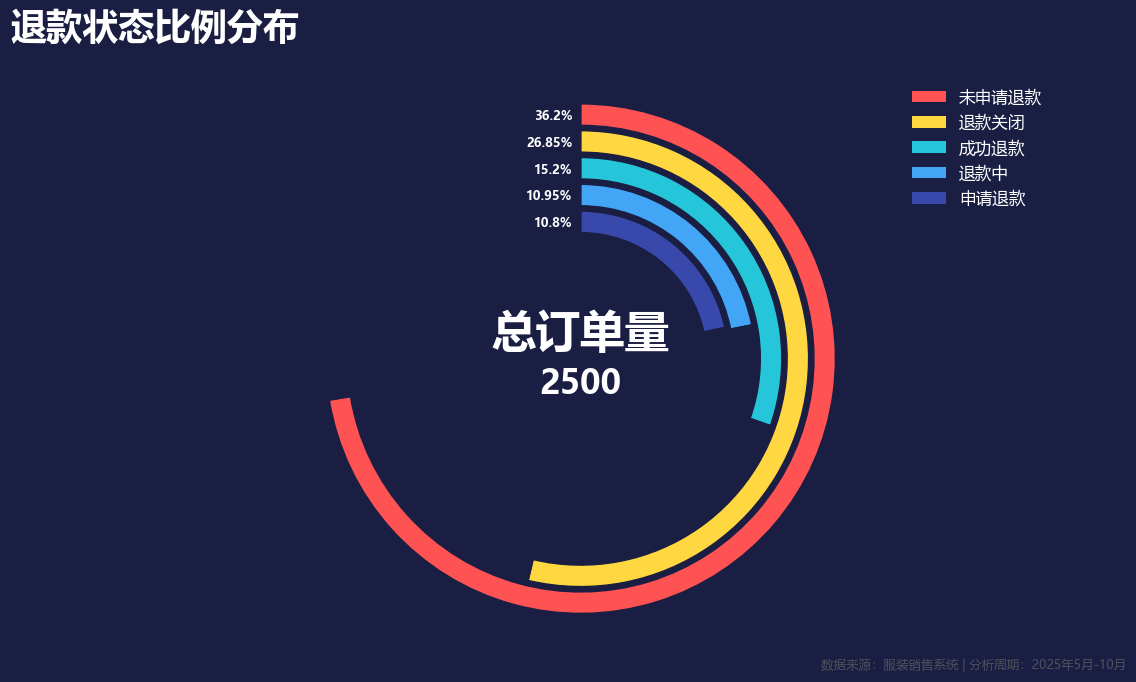

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# 设置中文字体支持
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'KaiTi']  # 支持中文
plt.rcParams['axes.unicode_minus'] = False  # 正确显示负号

try:
    # 读取数据
    df = pd.read_csv('../../数据生成/erp_order.csv', encoding='utf-8-sig')

    # 统计退款状态比例
    refund_status_counts = df['退款状态'].value_counts()
    total_orders = int(len(df) / 2)

    # 退款状态固定顺序
    ordered_refund_status = ['未申请退款', '申请退款', '退款中', '退款关闭', '成功退款']

    # 计算百分比（缺失的按0处理），并保留1位小数用于展示
    ratios = {status: refund_status_counts.get(status, 0) / total_orders for status in ordered_refund_status}
    percentages_map = {status: round(ratios[status] * 100, 1) for status in ordered_refund_status}

    # 将状态按占比从大到小排序，用于环的位置映射
    ranked_status_desc = sorted(
        ordered_refund_status,
        key=lambda status: (-percentages_map[status], ordered_refund_status.index(status))
    )

    # 固定颜色（外→内）
    BACKGROUND_COLOR = "#1A1E43"
    COLORS = ["#FF5252", "#FFD740", "#26C6DA", "#42A5F5", "#3949AB"]

    # 创建图形
    plt.figure(figsize=(12, 7), facecolor=BACKGROUND_COLOR)
    ax = plt.gca()
    ax.set_facecolor(BACKGROUND_COLOR)

    # 定义环之间的间隔
    spacing = 0.02

    # 创建环形图
    width = 0.08
    center = (0.5, 0.5)
    outer_radius = 0.95

    start_angle = 90

    # 用于垂直排列标签的参数
    label_x = -0.03
    label_y_base = 0.903
    label_spacing = 0.1

    for i in range(len(ordered_refund_status)):
        status = ranked_status_desc[i]
        perc = percentages_map[status]
        radius = outer_radius - i * (width + spacing)
        ax.pie(
            [perc, 100 - perc],
            radius=radius,
            colors=[COLORS[i], BACKGROUND_COLOR],
            startangle=start_angle,
            counterclock=False,
            wedgeprops={'width': width, 'edgecolor': BACKGROUND_COLOR}
        )

        if perc > 0:
            y_pos = label_y_base - i * label_spacing
            plt.text(
                label_x, y_pos,
                f"{perc/2}%",
                ha='right',
                va='center',
                color='white',
                fontsize=9,
                fontweight='bold'
            )

    # 标题与中心信息
    plt.figtext(0.02, 0.95, "退款状态比例分布",
                ha='left', fontsize=26, color='#ffffff', fontweight='bold')

    plt.text(0, 0.09, '总订单量',
             ha='center', va='center', color='#ffffff', fontsize=32, fontweight='bold')

    plt.text(0, -0.1, str(total_orders),
             ha='center', va='center', color='#ffffff', fontsize=24, fontweight='bold')

    # 创建图例
    legend_patches = [
        Patch(facecolor=COLORS[i], label=ranked_status_desc[i])
        for i in range(len(ordered_refund_status))
    ]

    ax.legend(handles=legend_patches,
              loc='upper right',
              bbox_to_anchor=(0.99, 1.2),
              frameon=False,
              labelcolor='#ffffff',
              fontsize=12)

    # 坐标轴与外观
    ax.set_xlim(-0.5, 1.8)
    ax.set_ylim(-0.5, 0.8)
    ax.set_aspect('equal', adjustable='box')
    ax.axis('off')

    plt.figtext(0.95, 0.05,
                '数据来源：服装销售系统 | 分析周期：2025年5月-10月',
                ha='right', fontsize=9, color='#666666', alpha=0.7)

    plt.tight_layout(rect=(0.13, 0.03, 1, 0.95))
    plt.savefig('退款状态比例分布.png', dpi=300, facecolor=BACKGROUND_COLOR, bbox_inches='tight')
    plt.show()

except Exception as e:
    print(f"图表生成失败: {str(e)}")
    raise

# 数据分析

  - **未申请退款**（红色）：占比最高，达到36.2%，表明大多数订单未发生退款请求，可能反映了较高的客户满意度或产品质量。

  - **退款关闭**（黄色）：占比26.85%，显示出一定数量的订单在退款申请后被关闭，可能与客户撤销申请或商家拒绝有关。

  - **成功退款**（浅蓝色）：占比15.2%，表明部分订单成功完成退款流程，这可能与客户服务处理效率或产品质量问题有关。

  - **退款中**（蓝色）：占比10.95%，显示出部分订单正在进行退款流程，这可能反映了退款处理的时效性。

  - **申请退款**（深蓝色）：占比10.8%，表明有部分订单客户已提交退款申请，但尚未进入处理阶段。


# 结论

从退款状态比例分布来看，未申请退款的订单占比最高，显示出整体客户满意度较高。然而，退款关闭和成功退款的比例也不容忽视，这可能指示需要进一步优化客户服务流程和产品质量控制。退款中和申请退款的状态表明退款流程的透明度和时效性有待提高。